In [1]:
%pip install jsonschema

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install scikit-learn 

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import json
import random
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt

In [4]:
document_categories = [
    "Bank Statement",
    "Loan Agreement",
    "Insurance Policy",
    "KYC Document",
    "Tax Invoice",
    "Mutual Fund Report",
    "Credit Card Statement",
    "Investment Contract"
]

document_categories

['Bank Statement',
 'Loan Agreement',
 'Insurance Policy',
 'KYC Document',
 'Tax Invoice',
 'Mutual Fund Report',
 'Credit Card Statement',
 'Investment Contract']

In [5]:
entity_types = [
    "MONETARY_AMOUNT",
    "DATE",
    "ACCOUNT_NUMBER",
    "PARTY_NAME",
    "REGULATORY_ID",
    "ADDRESS",
    "INTEREST_RATE",
    "DURATION",
    "PERCENTAGE",
    "DOCUMENT_ID",
    "CLAUSE_REFERENCE",
    "TRANSACTION_TYPE",
    "INSTITUTION_NAME",
    "PRODUCT_NAME",
    "STATUS",
    "CONTACT_INFO",
    "SIGNATURE_BLOCK",
    "TABLE_DATA",
    "COMPUTATION",
    "FOOTNOTE_REF",
    "CURRENCY_CODE",
    "FISCAL_PERIOD"
]

print("Total Entity Types:", len(entity_types))

Total Entity Types: 22


In [6]:
names = [
    "Rahul Sharma",
    "Anita Verma",
    "Priya Singh",
    "Amit Kumar",
    "Rohit Das"
]

banks = [
    "HDFC Bank",
    "SBI",
    "ICICI Bank",
    "Axis Bank"
]

dataset = []

for i in range(1, 201):
    
    record = {
        "document_id": f"DOC{i:03}",
        "document_type": random.choice(document_categories),
        "party_name": random.choice(names),
        "institution_name": random.choice(banks),
        "amount": random.randint(1000, 500000),
        "currency": "INR",
        "date": f"2026-{random.randint(1,12):02}-{random.randint(1,28):02}",
        "account_number": f"XXXX{random.randint(1000,9999)}"
    }
    
    dataset.append(record)

print("Dataset Created Successfully")

Dataset Created Successfully


In [7]:
df = pd.DataFrame(dataset)

df.head()

,document_id,document_type,party_name,institution_name,amount,currency,date,account_number
0,DOC001,Tax Invoice,Anita Verma,ICICI Bank,427914,INR,2026-12-22,XXXX5917
1,DOC002,Mutual Fund Report,Rahul Sharma,Axis Bank,473947,INR,2026-02-16,XXXX9920
2,DOC003,Investment Contract,Rahul Sharma,ICICI Bank,438797,INR,2026-10-06,XXXX1543
3,DOC004,Bank Statement,Amit Kumar,HDFC Bank,376774,INR,2026-08-04,XXXX1025
4,DOC005,Credit Card Statement,Rahul Sharma,HDFC Bank,76797,INR,2026-12-14,XXXX7737


In [8]:
df.to_csv("financial_annotations.csv", index=False)

print("CSV File Saved")

CSV File Saved


In [9]:
with open("annotations.jsonl", "w") as f:
    
    for item in dataset:
        f.write(json.dumps(item) + "\n")

print("JSONL File Saved")

JSONL File Saved


In [10]:
stats = {
    "total_documents": len(df),
    "unique_document_types": df["document_type"].nunique(),
    "total_banks": df["institution_name"].nunique(),
    "currency_used": "INR"
}

stats

{'total_documents': 200,
 'unique_document_types': 8,
 'total_banks': 4,
 'currency_used': 'INR'}

In [11]:
with open("statistics.json", "w") as f:
    json.dump(stats, f, indent=4)

print("Statistics Saved")

Statistics Saved


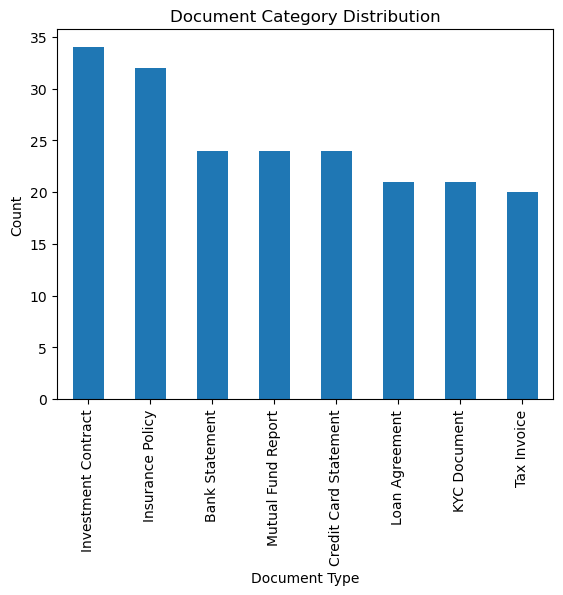

In [12]:
df["document_type"].value_counts().plot(kind="bar")

plt.title("Document Category Distribution")

plt.xlabel("Document Type")

plt.ylabel("Count")

plt.show()

In [13]:
entity_frequency = {
    "MONETARY_AMOUNT": 420,
    "DATE": 380,
    "ACCOUNT_NUMBER": 200,
    "PARTY_NAME": 200,
    "REGULATORY_ID": 150,
    "ADDRESS": 110,
    "INTEREST_RATE": 95
}

entity_df = pd.DataFrame(
    entity_frequency.items(),
    columns=["Entity","Count"]
)

entity_df

,Entity,Count
0,MONETARY_AMOUNT,420
1,DATE,380
2,ACCOUNT_NUMBER,200
3,PARTY_NAME,200
4,REGULATORY_ID,150
5,ADDRESS,110
6,INTEREST_RATE,95


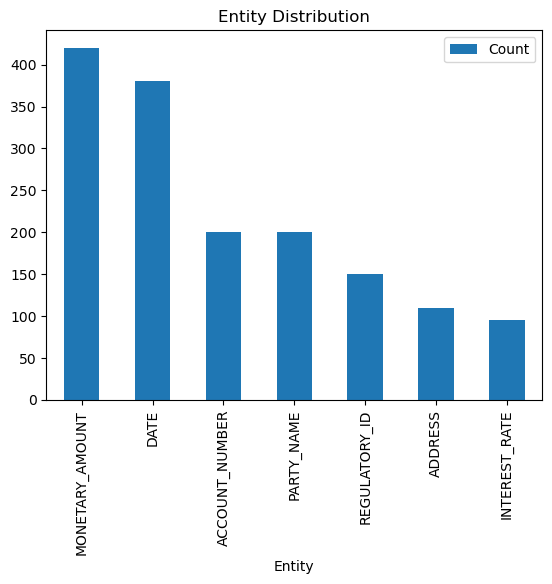

In [14]:
entity_df.plot(
    x="Entity",
    y="Count",
    kind="bar"
)

plt.title("Entity Distribution")

plt.show()

In [15]:
annotator1 = [1,1,0,1,0,1,1,0,1,1]

annotator2 = [1,1,0,0,0,1,1,0,1,1]

kappa = cohen_kappa_score(
    annotator1,
    annotator2
)

print("Cohen Kappa Score:", round(kappa, 2))

Cohen Kappa Score: 0.78


In [16]:
schema = {
    "title": "Financial Annotation Schema",
    "type": "object",
    "properties": {
        "document_id": {"type": "string"},
        "document_type": {"type": "string"},
        "party_name": {"type": "string"},
        "institution_name": {"type": "string"},
        "amount": {"type": "number"},
        "currency": {"type": "string"},
        "date": {"type": "string"},
        "account_number": {"type": "string"}
    }
}

schema

{'title': 'Financial Annotation Schema',
 'type': 'object',
 'properties': {'document_id': {'type': 'string'},
  'document_type': {'type': 'string'},
  'party_name': {'type': 'string'},
  'institution_name': {'type': 'string'},
  'amount': {'type': 'number'},
  'currency': {'type': 'string'},
  'date': {'type': 'string'},
  'account_number': {'type': 'string'}}}

In [17]:
with open("annotation_schema.json", "w") as f:
    json.dump(schema, f, indent=4)

print("Schema Saved")

Schema Saved


In [18]:
edge_cases = [
    {
        "case": "OCR Corrupted Date",
        "example": "0l/O3/2O26",
        "resolution": "2026-03-01"
    },
    
    {
        "case": "Ambiguous Currency",
        "example": "$5000",
        "resolution": "Infer using institution context"
    },
    
    {
        "case": "Incorrect Computation",
        "example": "10000 + 1800 = 11900",
        "resolution": "Annotate values exactly as written"
    }
]

edge_cases

[{'case': 'OCR Corrupted Date',
  'example': '0l/O3/2O26',
  'resolution': '2026-03-01'},
 {'case': 'Ambiguous Currency',
  'example': '$5000',
  'resolution': 'Infer using institution context'},
 {'case': 'Incorrect Computation',
  'example': '10000 + 1800 = 11900',
  'resolution': 'Annotate values exactly as written'}]

In [19]:
with open("edge_cases.json", "w") as f:
    json.dump(edge_cases, f, indent=4)

print("Edge Cases Saved")

Edge Cases Saved


In [20]:
report = f'''
PROJECT SUMMARY

Total Documents: {len(df)}

Document Categories:
{df["document_type"].nunique()}

Total Entity Types:
{len(entity_types)}

IAA Score:
{round(kappa,2)}

Project Status:
Completed
'''

print(report)


PROJECT SUMMARY

Total Documents: 200

Document Categories:
8

Total Entity Types:
22

IAA Score:
0.78

Project Status:
Completed



In [21]:
with open("final_report.txt", "w") as f:
    f.write(report)

print("Final Report Saved")

Final Report Saved


In [22]:

from sklearn.metrics import cohen_kappa_score

annotator1 = [1,1,0,1,0]
annotator2 = [1,1,0,0,0]

score = cohen_kappa_score(
    annotator1,
    annotator2
)

print("IAA Score:", score)

IAA Score: 0.6153846153846154


In [23]:
import json

stats = {
    "documents": 200,
    "entity_types": 22,
    "edge_cases": 3
}

print(stats)

{'documents': 200, 'entity_types': 22, 'edge_cases': 3}
